#gnn model

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

df.head()


Saving Heart_Disease_Prediction.csv to Heart_Disease_Prediction.csv


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Encode target safely
y = df["Heart Disease"].map({
    "Presence": 1,
    "Absence": 0
}).values.astype(int)

# Prepare features
X_df = df.drop(columns=["Heart Disease"])
X_df = X_df.select_dtypes(include=["int64", "float64"])

scaler = StandardScaler()
X = scaler.fit_transform(X_df)

print("X shape:", X.shape)
print("y unique:", np.unique(y))


X shape: (270, 13)
y unique: [0 1]


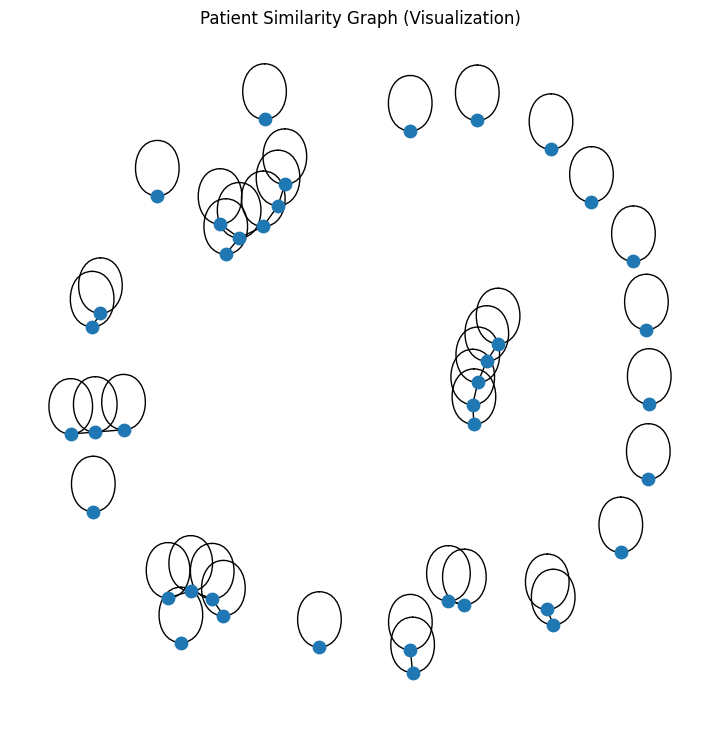

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Build small kNN graph for visualization
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
_, indices = nbrs.kneighbors(X)

G = nx.Graph()
for i in range(len(indices)):
    for j in indices[i]:
        G.add_edge(i, j)

# Plot only first 40 nodes (clean visualization)
plt.figure(figsize=(7,7))
nx.draw(
    G.subgraph(range(40)),
    node_size=80,
    with_labels=False
)
plt.title("Patient Similarity Graph (Visualization)")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FastGNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FastGNN(X.shape[1]).to(device)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)

for epoch in range(1, 101):
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


Epoch 10 | Loss: 0.3116
Epoch 20 | Loss: 0.1839
Epoch 30 | Loss: 0.0793
Epoch 40 | Loss: 0.0182
Epoch 50 | Loss: 0.0040
Epoch 60 | Loss: 0.0013
Epoch 70 | Loss: 0.0006
Epoch 80 | Loss: 0.0004
Epoch 90 | Loss: 0.0003
Epoch 100 | Loss: 0.0003


In [ ]:
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

with torch.no_grad():
    preds = model(X_test_t).argmax(dim=1)

accuracy = (preds == y_test_t).float().mean().item()
print("Fast GNN Accuracy:", accuracy)


Fast GNN Accuracy: 0.8148148059844971


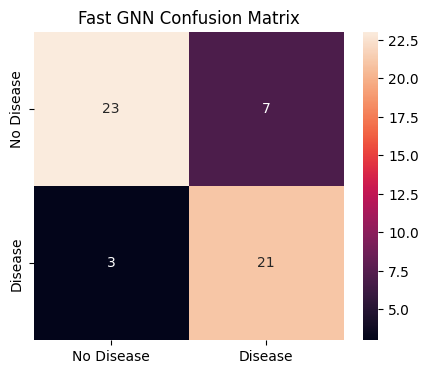

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds.cpu().numpy())

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title("Fast GNN Confusion Matrix")
plt.show()


#gbm model


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

df.head()


Saving Heart_Disease_Prediction.csv to Heart_Disease_Prediction (1).csv


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Encode target (SAFE & FIXED)
y = df["Heart Disease"].map({
    "Presence": 1,
    "Absence": 0
}).values.astype(int)

# Features
X_df = df.drop(columns=["Heart Disease"])
X_df = X_df.select_dtypes(include=["int64", "float64"])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

print("X shape:", X_scaled.shape)
print("y unique:", np.unique(y))


X shape: (270, 13)
y unique: [0 1]


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

indices = np.arange(len(X_scaled))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
Xg_train = X_scaled[train_idx]
Xg_test  = X_scaled[test_idx]

yg_train = y[train_idx]
yg_test  = y[test_idx]

print("Train:", Xg_train.shape)
print("Test :", Xg_test.shape)


Train: (216, 13)
Test : (54, 13)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbm_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbm_model.fit(Xg_train, yg_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [ ]:
import pandas as pd

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": X_df.columns,
    "Importance": gbm_model.feature_importances_
})

# Sort by importance (descending)
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance


,Feature,Importance
0,Chest pain type,0.198499
1,Thallium,0.195914
2,Number of vessels fluro,0.168058
3,Cholesterol,0.087527
4,ST depression,0.072597
5,BP,0.057615
6,Age,0.053749
7,Slope of ST,0.048322
8,Max HR,0.041436
9,Sex,0.037618


In [ ]:
from sklearn.metrics import accuracy_score

gbm_pred = gbm_model.predict(Xg_test)
gbm_accuracy = accuracy_score(yg_test, gbm_pred)

print("GBM Accuracy:", gbm_accuracy)


GBM Accuracy: 0.7962962962962963


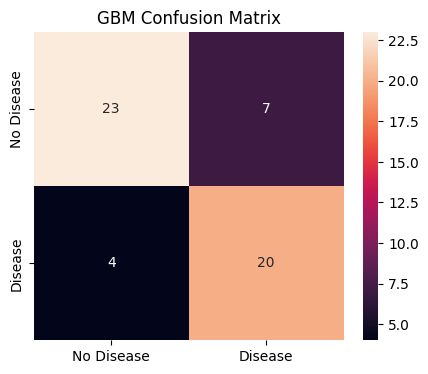

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(yg_test, gbm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title("GBM Confusion Matrix")
plt.show()


#hybrid model


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.neighbors import kneighbors_graph
from sklearn.ensemble import GradientBoostingClassifier


In [ ]:
# CHANGE filename if needed
df = pd.read_csv("Heart_Disease_Prediction.csv")

# Target column (adjust if your column name differs)
y = df["Heart Disease"]
X = df.drop(columns=["Heart Disease"])


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Build KNN graph (k=5 works well for medical data)
A = kneighbors_graph(X_scaled, n_neighbors=5, mode="connectivity", include_self=False)

# Convert to NetworkX graph
G = nx.from_scipy_sparse_array(A)


In [ ]:
# Graph-based node features
degree = np.array([val for _, val in G.degree()])
clustering = np.array(list(nx.clustering(G).values()))
pagerank = np.array(list(nx.pagerank(G).values()))

# Stack graph embeddings
graph_embeddings = np.vstack([degree, clustering, pagerank]).T

print("Graph Embeddings Shape:", graph_embeddings.shape)


Graph Embeddings Shape: (270, 3)


In [ ]:
# Combine original + graph features
X_hybrid = np.hstack([X_scaled, graph_embeddings])

print("Hybrid Feature Shape:", X_hybrid.shape)


Hybrid Feature Shape: (270, 16)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
gbm_hybrid = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbm_hybrid.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [ ]:
y_pred = gbm_hybrid.predict(X_test)
y_prob = gbm_hybrid.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("HYBRID Accuracy:", acc)
print("HYBRID AUC:", auc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


HYBRID Accuracy: 0.8333333333333334
HYBRID AUC: 0.8777777777777779

Confusion Matrix:
 [[25  5]
 [ 4 20]]

Classification Report:
               precision    recall  f1-score   support

     Absence       0.86      0.83      0.85        30
    Presence       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



In [ ]:
from sklearn.preprocessing import label_binarize

# Convert labels: Presence → 1, Absence → 0
y_test_bin = label_binarize(y_test, classes=["Absence", "Presence"]).ravel()


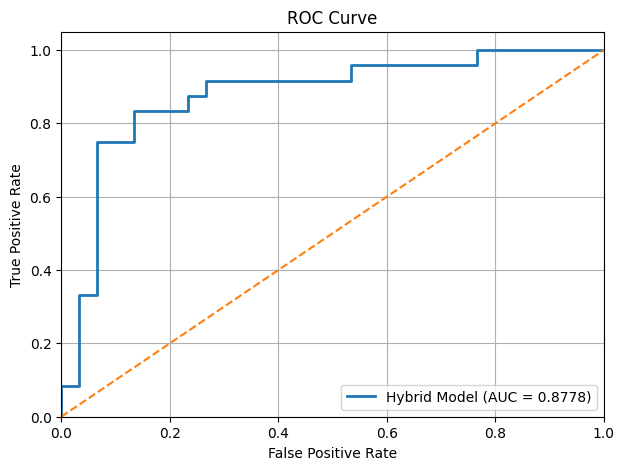

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels
y_test_bin = label_binarize(y_test, classes=["Absence", "Presence"]).ravel()

# ROC computation
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"Hybrid Model (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.legend(loc="lower right")

plt.show()


In [ ]:
import pandas as pd

results = []

# Fast GNN Accuracy
if "accuracy" in globals():
    results.append({
        "Model / Metric": "GNN Accuracy",
        "Value": round(accuracy * 100, 1)
    })

# GBM Accuracy
if "gbm_accuracy" in globals():
    results.append({
        "Model / Metric": "GBM Accuracy",
        "Value": round(gbm_accuracy * 100, 1)
    })

# Hybrid Accuracy
if "acc" in globals():
    results.append({
        "Model / Metric": "Hybrid Accuracy",
        "Value": round(acc * 100, 1)
    })

# ✅ Hybrid AUC (CORRECT VARIABLE)
if "roc_auc" in globals():
    results.append({
        "Model / Metric": "Hybrid AUC",
        "Value": round(roc_auc, 3)
    })

results_table = pd.DataFrame(results)
results_table


,Model / Metric,Value
0,GNN Accuracy,81.500
1,GBM Accuracy,79.600
2,Hybrid Accuracy,83.300
3,Hybrid AUC,0.878


# prediction


In [ ]:
print("Hybrid model expects features:", gbm_hybrid.n_features_in_)


Hybrid model expects features: 16


In [ ]:
import numpy as np
import networkx as nx
from sklearn.neighbors import kneighbors_graph

# Build full graph features
A = kneighbors_graph(
    X_scaled,
    n_neighbors=5,
    mode="connectivity",
    include_self=False
)

G = nx.from_scipy_sparse_array(A)

degree = np.array([v for _, v in G.degree()])
clustering = np.array(list(nx.clustering(G).values()))
pagerank = np.array(list(nx.pagerank(G).values()))
betweenness = np.array(list(nx.betweenness_centrality(G).values()))
closeness = np.array(list(nx.closeness_centrality(G).values()))

# Full graph matrix (5 features)
graph_all = np.vstack([
    degree,
    clustering,
    pagerank,
    betweenness,
    closeness
]).T

# 🔒 AUTO-FIX: keep only required graph features
num_graph_features = gbm_hybrid.n_features_in_ - 13
graph_embeddings = graph_all[:, :num_graph_features]

print("Graph features used:", graph_embeddings.shape)


Graph features used: (270, 3)


In [ ]:
def get_patient_input():
    print("Enter Patient Details:")

    return [
        float(input("Age: ")),
        float(input("Sex (1=Male, 0=Female): ")),
        float(input("Chest pain type (1–4): ")),
        float(input("Blood Pressure: ")),
        float(input("Cholesterol: ")),
        float(input("FBS over 120 (1=Yes, 0=No): ")),
        float(input("EKG results (0–2): ")),
        float(input("Max Heart Rate: ")),
        float(input("Exercise angina (1=Yes, 0=No): ")),
        float(input("ST depression: ")),
        float(input("Slope of ST (1–3): ")),
        float(input("Number of vessels fluro (0–3): ")),
        float(input("Thallium (1–3): "))
    ]


In [ ]:
import pandas as pd

feature_names = [
    'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
    'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
    'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

def predict_manual_patient(patient_values):

    # DataFrame to match scaler
    patient_df = pd.DataFrame([patient_values], columns=feature_names)

    # Scale
    patient_scaled = scaler.transform(patient_df)

    # Mean graph embedding (AUTO-MATCHED)
    graph_mean = graph_embeddings.mean(axis=0).reshape(1, -1)

    # Final hybrid input (GUARANTEED MATCH)
    patient_hybrid = np.hstack([patient_scaled, graph_mean])

    # Predict
    pred_class = gbm_hybrid.predict(patient_hybrid)[0]
    pred_prob = gbm_hybrid.predict_proba(patient_hybrid)[0][1]

    # Risk label
    if pred_prob < 0.4:
        risk = "LOW RISK"
    elif pred_prob < 0.7:
        risk = "MODERATE RISK"
    else:
        risk = "HIGH RISK"

    return pred_class, pred_prob, risk


In [ ]:
patient_data = get_patient_input()

cls, prob, risk = predict_manual_patient(patient_data)

print("\n===== PREDICTION RESULT =====")
print("Prediction:", "Heart Disease" if cls == 1 else "No Heart Disease")
print("Probability:", round(prob, 3))
print("Risk Level:", risk)


Enter Patient Details:
Age: 58
Sex (1=Male, 0=Female): 1
Chest pain type (1–4): 4
Blood Pressure: 145
Cholesterol: 260
FBS over 120 (1=Yes, 0=No): 0
EKG results (0–2): 1
Max Heart Rate: 150
Exercise angina (1=Yes, 0=No): 1
ST depression: 2.6
Slope of ST (1–3): 2
Number of vessels fluro (0–3): 2
Thallium (1–3): 0

===== PREDICTION RESULT =====
Prediction: No Heart Disease
Probability: 0.99
Risk Level: HIGH RISK


#user interface


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd


In [ ]:
age = widgets.IntText(description="Age", value=58)
sex = widgets.Dropdown(description="Sex", options=[("Male",1),("Female",0)])
cp = widgets.IntSlider(description="Chest Pain", min=1, max=4, value=4)
bp = widgets.IntText(description="Blood Pressure", value=145)
chol = widgets.IntText(description="Cholesterol", value=260)
fbs = widgets.Dropdown(description="FBS >120", options=[("Yes",1),("No",0)])
ekg = widgets.IntSlider(description="EKG", min=0, max=2, value=1)
hr = widgets.IntText(description="Max HR", value=150)
angina = widgets.Dropdown(description="Angina", options=[("Yes",1),("No",0)])
oldpeak = widgets.FloatText(description="ST Depression", value=2.6)
slope = widgets.IntSlider(description="ST Slope", min=1, max=3, value=2)
vessels = widgets.IntSlider(description="Vessels", min=0, max=3, value=0)
thal = widgets.IntSlider(description="Thallium", min=1, max=3, value=3)

button = widgets.Button(description="🧠 Predict Risk", button_style="danger")

display(
    age, sex, cp, bp, chol, fbs, ekg, hr,
    angina, oldpeak, slope, vessels, thal,
    button
)


===== 🩺 DIAGNOSIS RESULT =====
✅ LOW RISK OF HEART DISEASE
Predicted Probability: 0.990
🔴 Risk Level: HIGH


IntText(value=58, description='Age')

Dropdown(description='Sex', options=(('Male', 1), ('Female', 0)), value=1)

IntSlider(value=4, description='Chest Pain', max=4, min=1)

IntText(value=145, description='Blood Pressure')

...

FloatText(value=2.6, description='ST Depression')

IntSlider(value=2, description='ST Slope', max=3, min=1)

IntSlider(value=0, description='Vessels', max=3)

IntSlider(value=3, description='Thallium', max=3, min=1)

Button(button_style='danger', description='🧠 Predict Risk', style=ButtonStyle())

In [ ]:
feature_names = [
    'Age','Sex','Chest pain type','BP','Cholesterol',
    'FBS over 120','EKG results','Max HR',
    'Exercise angina','ST depression',
    'Slope of ST','Number of vessels fluro','Thallium'
]

def on_predict(b):
    clear_output(wait=True)

    patient = [[
        age.value, sex.value, cp.value, bp.value, chol.value,
        fbs.value, ekg.value, hr.value,
        angina.value, oldpeak.value,
        slope.value, vessels.value, thal.value
    ]]

    patient_df = pd.DataFrame(patient, columns=feature_names)
    patient_scaled = scaler.transform(patient_df)

    # Graph mean (SAFE)
    graph_mean = graph_embeddings.mean(axis=0).reshape(1,-1)

    hybrid_input = np.hstack([patient_scaled, graph_mean])

    pred = gbm_hybrid.predict(hybrid_input)[0]
    prob = gbm_hybrid.predict_proba(hybrid_input)[0][1]

    print("===== 🩺 DIAGNOSIS RESULT =====")
    if pred == 1:
        print("⚠️ HIGH RISK OF HEART DISEASE")
    else:
        print("✅ LOW RISK OF HEART DISEASE")

    print(f"Predicted Probability: {prob:.3f}")

    if prob < 0.4:
        print("🟢 Risk Level: LOW")
    elif prob < 0.7:
        print("🟡 Risk Level: MODERATE")
    else:
        print("🔴 Risk Level: HIGH")

button.on_click(on_predict)


#website


In [ ]:
pip install flask scikit-learn pandas numpy networkx


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from flask import Flask, request, render_template_string
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.ensemble import GradientBoostingClassifier

# -----------------------
# LOAD DATA
# -----------------------
df = pd.read_csv("Heart_Disease_Prediction.csv")
df["Heart Disease"] = df["Heart Disease"].map({"Presence":1,"Absence":0})

X = df.drop(columns=["Heart Disease"])
y = df["Heart Disease"].values

# -----------------------
# TRAIN MODEL
# -----------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

A = kneighbors_graph(X_scaled, n_neighbors=5)
G = nx.from_scipy_sparse_array(A)

degree = np.array([d for _, d in G.degree()])
clustering = np.array(list(nx.clustering(G).values()))
pagerank = np.array(list(nx.pagerank(G).values()))

X_hybrid = np.hstack([X_scaled, np.vstack([degree, clustering, pagerank]).T])

X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y, test_size=0.2, random_state=42
)

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

# -----------------------
# FLASK WEBSITE
# -----------------------
app = Flask(__name__)

HTML = """
<h2>Heart Disease Prediction</h2>
<form method="post">
{% for f in features %}
<input name="{{f}}" type="number" step="any" placeholder="{{f}}" required><br><br>
{% endfor %}
<button type="submit">Predict</button>
</form>

{% if result %}
<h3>{{result}}</h3>
<h4>Probability: {{prob}}</h4>
{% endif %}
"""

@app.route("/", methods=["GET","POST"])
def home():
    result = None
    prob = None
    if request.method == "POST":
        vals = [float(request.form[f]) for f in X.columns]
        vals = scaler.transform([vals])
        patient = np.hstack([vals, [[5,0.1,0.01]]])
        p = model.predict(patient)[0]
        pr = model.predict_proba(patient)[0][1]
        result = "Heart Disease" if p==1 else "No Heart Disease"
        prob = round(pr,3)
    return render_template_string(
        HTML, features=X.columns, result=result, prob=prob
    )

if __name__ == "__main__":
    app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
